# 1 · Backend and Context

> **The idea in one line.** In SpaceCore, *which array library you compute with* is an
> explicit, swappable object — not a hard-wired `import numpy`.

Most numerical Python code bakes a backend into every line: `np.zeros`, `np.linalg.solve`,
`jnp.dot`. Moving such code from NumPy to JAX (for autodiff/JIT/GPU) or to Torch means a
rewrite, and the *rules* of the computation — the dtype, what counts as a valid input —
live only in your head.

SpaceCore pulls those decisions into one place, the **`Context`**:

* a **`BackendOps`** — the numerical contract (`matmul`, `einsum`, `eigh`, …) implemented by
  NumPy, JAX, Torch, or CuPy;
* a **default `dtype`** for the arrays you create;
* a **checking policy** (`check_level`) that decides how much runtime validation happens.

Every space, operator, and functional you will meet in the next tutorials carries a context.
This first notebook is about that foundation: what a context *is*, how to write code that runs
unchanged on two backends, and how to dial validation up or down.

**You will learn to**

1. create a `Context` and read its parts;
2. write one function that runs identically on NumPy **and** JAX through `ctx.ops`;
3. use `check_level` to make bugs loud (or silent);
4. move an object from one backend to another with `.convert(...)`.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import spacecore as sc

# A clean, consistent palette + style for every figure in the tutorials.
BLUE, INDIGO, CYAN = "#2563eb", "#4f46e5", "#0891b2"
PINK, AMBER, GREEN = "#db2777", "#d97706", "#059669"
SLATE, GRID = "#334155", "#e5e9f0"

mpl.rcParams.update({
    "figure.figsize": (7.2, 4.2), "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": SLATE, "axes.linewidth": 1.0,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": SLATE,
    "axes.labelcolor": SLATE, "axes.labelsize": 11,
    "xtick.color": SLATE, "ytick.color": SLATE,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "font.size": 11,
    "legend.frameon": False, "legend.fontsize": 10,
    "lines.linewidth": 2.4, "lines.markersize": 6, "image.cmap": "magma",
})
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(
    color=[BLUE, PINK, GREEN, AMBER, INDIGO, CYAN])

print("spacecore", sc.__version__, "| numpy", np.__version__)

spacecore 0.4.0 | numpy 2.4.2


## 1 · Anatomy of a context

A context bundles three decisions. The picture below is the mental model to keep.

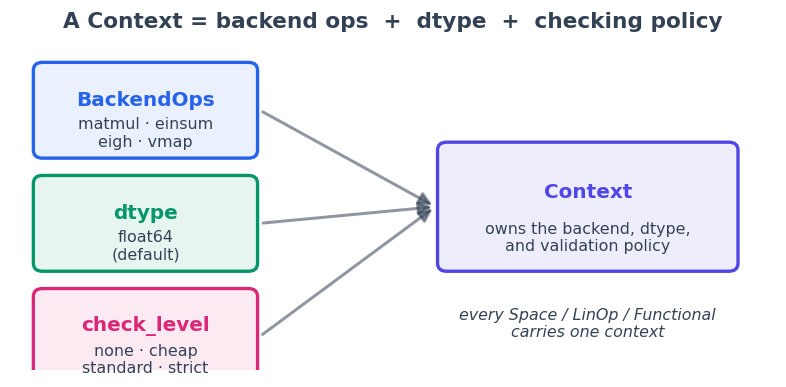

In [2]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(8.2, 3.6)); ax.axis("off")
ax.set_xlim(0, 10); ax.set_ylim(0, 5)

def box(x, y, w, h, title, sub, color):
    p = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.12",
                       linewidth=2, edgecolor=color, facecolor=color + "18")
    ax.add_patch(p)
    ax.text(x + w/2, y + h*0.62, title, ha="center", va="center",
            fontsize=12, fontweight="bold", color=color)
    ax.text(x + w/2, y + h*0.26, sub, ha="center", va="center", fontsize=9.5, color=SLATE)

box(0.3, 3.2, 2.9, 1.4, "BackendOps", "matmul · einsum\neigh · vmap", BLUE)
box(0.3, 1.5, 2.9, 1.4, "dtype", "float64\n(default)", GREEN)
box(0.3, -0.2, 2.9, 1.4, "check_level", "none · cheap\nstandard · strict", PINK)
box(5.6, 1.5, 3.9, 1.9, "Context", "owns the backend, dtype,\nand validation policy", INDIGO)

for y in (3.9, 2.2, 0.5):
    ax.add_patch(FancyArrowPatch((3.25, y), (5.55, 2.45), arrowstyle="-|>",
                 mutation_scale=16, lw=1.8, color=SLATE, alpha=0.55))
ax.text(7.55, 0.7, "every Space / LinOp / Functional\ncarries one context",
        ha="center", va="center", fontsize=9.5, style="italic", color=SLATE)
ax.set_title("A Context = backend ops  +  dtype  +  checking policy", loc="center")
plt.show()

## 2 · Create a context and read its parts

`Context(ops, dtype=...)` is all you need. `NumpyOps` is always available; the others
(`JaxOps`, `TorchOps`, `CuPyOps`) appear only when their optional dependency is installed.

In [3]:
ctx = sc.Context(sc.NumpyOps(), dtype=np.float64)

print("backend family :", ctx.ops.family)
print("default dtype  :", ctx.dtype)
print("check level    :", ctx.check_level)   # direct construction defaults to "standard"

# `asarray` materialises data on this backend at this dtype:
x = ctx.asarray([1.0, 2.0, 3.0])
print("asarray dtype  :", x.dtype, "->", x)

backend family : numpy
default dtype  : float64
check level    : standard
asarray dtype  : float64 -> [1. 2. 3.]


The context never *owns* arrays; it is a small, immutable description of *how* to make
and check them. `ctx.asarray` is the canonical way to bring Python/NumPy data onto the
context's backend and dtype.

## 3 · `BackendOps`: one function, two backends

`ctx.ops` is the numerical contract. If you write your computation against it instead of
against `numpy` directly, the *same function* runs on any backend. Here is a small routine
that builds a Gaussian kernel matrix and smooths a signal — written once.

In [4]:
def smooth_with_gaussian(ctx, signal, sigma=1.5):
    """Backend-agnostic: only touches ctx.ops and ctx.asarray."""
    ops = ctx.ops
    x = ctx.asarray(signal)
    n = x.shape[0]
    idx = ops.arange(0, n, dtype=ctx.dtype)
    # pairwise squared distances via broadcasting, then a normalised Gaussian kernel
    d2 = (idx[:, None] - idx[None, :]) ** 2
    K = ops.exp(-d2 / (2.0 * sigma ** 2))
    K = K / ops.sum(K, axis=1)[:, None]
    return ops.matmul(K, x), K

rng = np.random.default_rng(0)
raw = np.cumsum(rng.standard_normal(60))        # a noisy random walk
sm_np, K_np = smooth_with_gaussian(ctx, raw)
print("numpy output dtype:", sm_np.dtype)

numpy output dtype: float64


Now run the **exact same function** through a JAX context. We enable 64-bit mode first so
JAX matches NumPy's `float64` (JAX defaults to `float32`).

In [5]:
try:
    import jax
    jax.config.update("jax_enable_x64", True)
    ctx_jax = sc.Context(sc.JaxOps(), dtype=jax.numpy.float64)
    sm_jax, K_jax = smooth_with_gaussian(ctx_jax, raw)   # same function, new backend
    max_diff = float(np.max(np.abs(np.asarray(sm_jax) - np.asarray(sm_np))))
    HAVE_JAX = True
    print("jax output type   :", type(sm_jax).__name__)
    print("max abs(numpy - jax):", max_diff)
except ImportError:
    HAVE_JAX = False
    print("JAX not installed — skipping the JAX backend comparison.")

jax output type   : ArrayImpl
max abs(numpy - jax): 1.7763568394002505e-15


W0622 05:48:02.899710 11890930 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


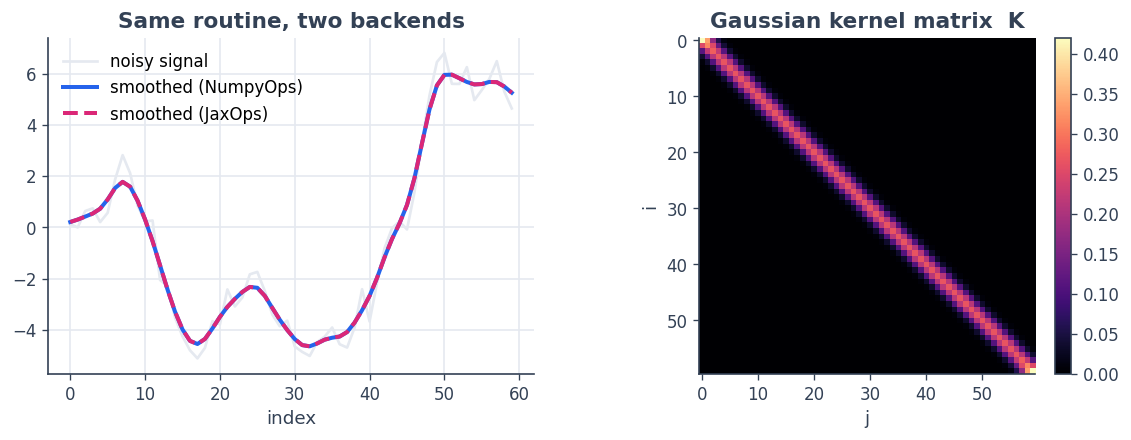

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.8))

axes[0].plot(raw, color=GRID, lw=1.6, label="noisy signal")
axes[0].plot(np.asarray(sm_np), color=BLUE, label="smoothed (NumpyOps)")
if HAVE_JAX:
    axes[0].plot(np.asarray(sm_jax), color=PINK, ls="--", label="smoothed (JaxOps)")
axes[0].set_title("Same routine, two backends"); axes[0].set_xlabel("index")
axes[0].legend(loc="upper left")

im = axes[1].imshow(np.asarray(K_np), cmap="magma")
axes[1].set_title("Gaussian kernel matrix  K"); axes[1].set_xlabel("j"); axes[1].set_ylabel("i")
axes[1].grid(False)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

The blue (NumPy) and dashed-pink (JAX) curves lie on top of each other to ~1e-13. The
function never mentioned `numpy` or `jax` — only `ctx.ops`. That is the whole point of a
backend abstraction: **write the math once, choose the engine later.**

## 4 · `check_level`: how loud should bugs be?

A context also carries a validation policy. There are four levels, cheapest to strictest:

| level | meaning |
|---|---|
| `none` | no validation — fastest, trust the caller |
| `cheap` | O(1) structural checks (shape, dtype, backend) |
| `standard` | the default — the everyday safety net |
| `strict` | adds expensive probes (e.g. adjoint dot-tests) |

The same wrong input is caught at `standard` but silently accepted at `none`.

In [7]:
ctx_checked = sc.Context(sc.NumpyOps(), dtype=np.float64, check_level="standard")
ctx_silent  = sc.Context(sc.NumpyOps(), dtype=np.float64, check_level="none")

X_checked = sc.DenseVectorSpace((3,), ctx_checked)
X_silent  = sc.DenseVectorSpace((3,), ctx_silent)

wrong = np.zeros(4)   # 4 entries for a 3-dimensional space

try:
    X_checked.check_member(wrong)
except sc.SpaceValidationError as exc:
    print("standard  ->", exc)

X_silent.check_member(wrong)
print("none      -> accepted silently (no exception raised)")

standard  -> Expected shape (3,), got (4,)
none      -> accepted silently (no exception raised)


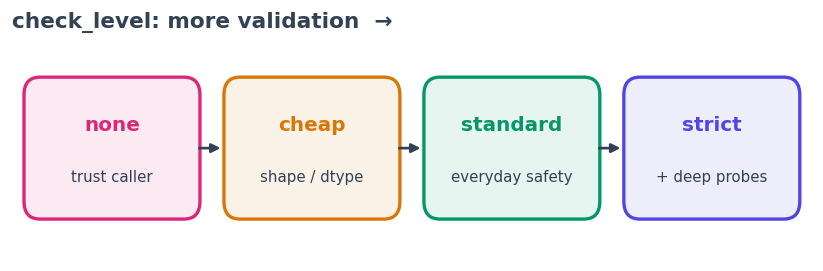

In [8]:
fig, ax = plt.subplots(figsize=(8.6, 2.4)); ax.axis("off")
ax.set_xlim(0, 4); ax.set_ylim(0, 1)
levels = [("none", "trust caller", PINK),
          ("cheap", "shape / dtype", AMBER),
          ("standard", "everyday safety", GREEN),
          ("strict", "+ deep probes", INDIGO)]
for i, (name, sub, color) in enumerate(levels):
    ax.add_patch(FancyBboxPatch((i + 0.08, 0.2), 0.84, 0.6,
                 boxstyle="round,pad=0.02,rounding_size=0.08",
                 lw=2, edgecolor=color, facecolor=color + "18"))
    ax.text(i + 0.5, 0.58, name, ha="center", fontsize=12, fontweight="bold", color=color)
    ax.text(i + 0.5, 0.35, sub, ha="center", fontsize=9, color=SLATE)
    if i < 3:
        ax.annotate("", xy=(i + 1.06, 0.5), xytext=(i + 0.92, 0.5),
                    arrowprops=dict(arrowstyle="-|>", color=SLATE, lw=1.6))
ax.set_title("check_level: more validation  →", loc="left")
plt.show()

Use `none` in tight production loops you have already validated, and `standard`/`strict`
while developing. (Older code used `enable_checks=True/False`; that still works but is
deprecated in favour of `check_level`.)

## 5 · Switching backends with `.convert(...)`

Because a context is immutable, you do not mutate a backend — you rebuild an object on a new
context. Every SpaceCore object (space, operator, functional) supports `.convert(...)`,
which accepts a `Context`, a backend name, or a `BackendFamily`.

In [9]:
X_np = sc.DenseVectorSpace((3,), ctx)            # numpy
print("original :", X_np.ops.family)

if HAVE_JAX:
    X_to_jax = X_np.convert("jax")               # rebuilt on JAX
    print("converted:", X_to_jax.ops.family, "(new object:", X_to_jax is not X_np, ")")
    print("same ctx returns self:", X_np.convert(ctx) is X_np)
else:
    print("JAX not available; convert('jax') would rebuild this space on JAX.")

original : numpy
converted: jax (new object: True )
same ctx returns self: True


## Recap

* A **`Context`** = backend ops + default dtype + checking policy. It is immutable and owns
  no data.
* Writing code against **`ctx.ops`** (not `numpy`) makes it backend-portable — we ran one
  routine on NumPy and JAX with identical results.
* **`check_level`** (`none` → `strict`) trades speed for safety; `standard` is the default.
* **`.convert(...)`** rebuilds any SpaceCore object on another backend.

**Next:** [2 · Linear algebra](02_linear_algebra.ipynb) — build spaces and operators and
solve a linear system with conjugate gradients.